In [1]:

import os
import sys
sys.path.append("../..")
from tqdm import tqdm
import pandas as pd
import numpy as np
import torch

import nibabel as nib

#import seaborn as sns
import matplotlib.pyplot as plt

from scipy.ndimage import median_filter, binary_erosion, binary_dilation, binary_fill_holes
import utils.scores as scores

#### Folders

In [2]:
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"
#ROOT_DIR = "/home/fehrdelt/bettik/"
#ROOT_DIR = "/home/rivage/bettik/"

In [3]:
adc_anomaly_maps_select_params_folder = f"{ROOT_DIR}datasets/anomaly_maps/exp_2_2_select_params/small/"
adc_anomaly_maps_folder = f"{ROOT_DIR}datasets/anomaly_maps/exp_2_2/small/"

flair_anomaly_maps_select_params_folder = f"{ROOT_DIR}datasets/anomaly_maps/exp_3_2_select_params/small/"
flair_anomaly_maps_folder = f"{ROOT_DIR}datasets/anomaly_maps/exp_3_2/small/"

combined_anomaly_maps_select_params_folder = f"{ROOT_DIR}datasets/anomaly_maps/combined_ano_maps_select_params/small/"
combined_anomaly_maps_folder = f"{ROOT_DIR}datasets/anomaly_maps/combined_ano_maps/small/"

combined_masks_folder = f"{ROOT_DIR}datasets/final_soop_dataset_small/masks_combined_registered/"


#### Make the combined ano maps

Select params

In [4]:
adc_timesteps = 130
flair_timesteps = 230

In [5]:
adc_ano_maps_select_params = os.listdir(adc_anomaly_maps_select_params_folder)
adc_ano_maps_select_params = sorted([f for f in adc_ano_maps_select_params if f"_t_{adc_timesteps}" in f])

adc_ano_maps = os.listdir(adc_anomaly_maps_folder)
adc_ano_maps = sorted([f for f in adc_ano_maps if "seg" not in f])


flair_ano_maps_select_params = os.listdir(flair_anomaly_maps_select_params_folder)
flair_ano_maps_select_params = sorted([f for f in flair_ano_maps_select_params if f"_t_{flair_timesteps}" in f])

flair_ano_maps = os.listdir(flair_anomaly_maps_folder)
flair_ano_maps = sorted([f for f in flair_ano_maps if "seg" not in f])

In [6]:
for file in tqdm(adc_ano_maps_select_params):
    adc_file = os.path.join(adc_anomaly_maps_select_params_folder, file)
    adc_img = nib.load(adc_file)

    try:
        flair_file = os.path.join(flair_anomaly_maps_select_params_folder, file.replace(f"_t_{adc_timesteps}", f"_t_{flair_timesteps}"))
        flair_img = nib.load(flair_file)
    except:
        continue
    
    combined_filepath = os.path.join(combined_anomaly_maps_select_params_folder, file.replace(f"_t_{adc_timesteps}", ""))

    adc_data = adc_img.get_fdata()
    flair_data = flair_img.get_fdata()

    combined_data = (adc_data + flair_data)/2 # average of the two anomaly maps

    combined_img = nib.Nifti1Image(combined_data, affine=adc_img.affine, header=adc_img.header)
    nib.save(combined_img, combined_filepath)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 72/72 [01:20<00:00,  1.11s/it]


final metrics ano maps

In [7]:
for file in tqdm(os.listdir(adc_anomaly_maps_folder)):
    adc_file = os.path.join(adc_anomaly_maps_folder, file)
    adc_img = nib.load(adc_file)

    try:
        flair_file = os.path.join(flair_anomaly_maps_folder, file)
        flair_img = nib.load(flair_file)
    except:
        continue
    
    combined_filepath = os.path.join(combined_anomaly_maps_folder, file)

    adc_data = adc_img.get_fdata()
    flair_data = flair_img.get_fdata()

    combined_data = (adc_data + flair_data)/2 # average of the two anomaly maps

    combined_img = nib.Nifti1Image(combined_data, affine=adc_img.affine, header=adc_img.header)
    nib.save(combined_img, combined_filepath)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 72/72 [01:35<00:00,  1.32s/it]


#### Use multicontrast_select_params.py

#### Read csv file with best params computed from multicontrast_select_params.py

In [ ]:
GROUP = "small"

In [9]:
best_params_df = pd.read_csv(ROOT_DIR+f"AnoDiffExperiments/multicontrast/best_params_{GROUP}.csv")
best_params_dict = dict(zip(best_params_df['parameter'], best_params_df['value']))

best_median_filter_size = int(best_params_dict['median_filter_size'])
best_threshold = float(best_params_dict['threshold'])
best_erosion_dilation_iterations = int(best_params_dict['erosion_dilation_iterations'])
best_binary_fill_holes = int(best_params_dict['binary_fill_holes'])

In [10]:
metrics_result_text = f"Best Median Filter Size: {best_median_filter_size}\n"
metrics_result_text += f"Best Threshold: {best_threshold:.4f}\n"
metrics_result_text += f"Best Erosion Dilation Iterations: {best_erosion_dilation_iterations}\n"
metrics_result_text += f"Best Binary Fill Holes: {best_binary_fill_holes}\n"
print(metrics_result_text)

Best Median Filter Size: 5
Best Threshold: 0.0600
Best Erosion Dilation Iterations: 0
Best Binary Fill Holes: 0



In [12]:
adc_anomaly_maps_select_params_folder = f"{ROOT_DIR}datasets/anomaly_maps/exp_2_2_select_params/{GROUP}/"
adc_anomaly_maps_folder = f"{ROOT_DIR}datasets/anomaly_maps/exp_2_2/{GROUP}/"

flair_anomaly_maps_select_params_folder = f"{ROOT_DIR}datasets/anomaly_maps/exp_3_2_select_params/{GROUP}/"
flair_anomaly_maps_folder = f"{ROOT_DIR}datasets/anomaly_maps/exp_3_2/{GROUP}/"

combined_anomaly_maps_select_params_folder = f"{ROOT_DIR}datasets/anomaly_maps/combined_ano_maps_select_params/{GROUP}"
combined_anomaly_maps_folder = f"{ROOT_DIR}datasets/anomaly_maps/combined_ano_maps/{GROUP}/"

combined_masks_folder = f"{ROOT_DIR}datasets/final_soop_dataset_small/masks_combined_registered/"

combined_ano_maps_select_params = os.listdir(combined_anomaly_maps_select_params_folder)
combined_ano_maps_select_params = sorted([f for f in combined_ano_maps_select_params if "seg" not in f])

combined_ano_maps = os.listdir(combined_anomaly_maps_folder)
combined_ano_maps = sorted([f for f in combined_ano_maps if "seg" not in f])

In [13]:

combined_masks_select_params = sorted([path for path in combined_ano_maps_select_params])

combined_masks = sorted([path.replace("ano_map_", "") for path in combined_ano_maps])



In [14]:
iou_scores = []
dice_scores = []
hausdorff_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

In [15]:
for file in tqdm(os.listdir(combined_anomaly_maps_folder)):
    if "seg" in file:
        continue

    combined_map_path = os.path.join(combined_anomaly_maps_folder, file)
    combined_map_img = nib.load(combined_map_path)
    combined_map_data = combined_map_img.get_fdata()

    mask_path = os.path.join(combined_masks_folder, file.replace("ano_map_", ""))
    mask_img = nib.load(mask_path)
    mask_data = mask_img.get_fdata()

    # Apply post-processing with the best parameters
    if best_median_filter_size > 1:
        combined_map_data = median_filter(combined_map_data, size=best_median_filter_size)

    binary_mask = combined_map_data > best_threshold

    if best_erosion_dilation_iterations > 0:
        binary_mask = binary_erosion(binary_mask, iterations=best_erosion_dilation_iterations)
        binary_mask = binary_dilation(binary_mask, iterations=best_erosion_dilation_iterations)

    if best_binary_fill_holes:
        binary_mask = binary_fill_holes(binary_mask)

    # if ano_segmentation is not torch tensor, convert it to torch tensor
    if not isinstance(binary_mask, torch.Tensor):
        ano_segmentation = torch.from_numpy(binary_mask.astype(np.float32))
    # make sure it is in bchw format (1, 1, D, H, W)
    if ano_segmentation.ndim == 3:
        ano_segmentation = ano_segmentation.unsqueeze(0).unsqueeze(0)
        
    # same for test_masks
    if not isinstance(mask_data, torch.Tensor):
        test_masks = torch.from_numpy(mask_data.astype(np.float32))
    if test_masks.ndim == 3:
        test_masks = test_masks.unsqueeze(0).unsqueeze(0)


    # Compute metrics
    iou_score, dice_score, hausdorff_distance, precision_score, recall_score, f1_score = scores.compute_scores(ano_segmentation, test_masks)


    iou_scores.append(iou_score)
    dice_scores.append(dice_score)
    hausdorff_scores.append(hausdorff_distance)
    precision_scores.append(precision_score)
    recall_scores.append(recall_score)
    f1_scores.append(f1_score)





100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 84/84 [04:20<00:00,  3.10s/it]


In [16]:


# Flatten nested lists before converting to numpy array
flat_iou = [item for sublist in iou_scores for item in sublist]
flat_dice = [item for sublist in dice_scores for item in sublist]
flat_hausdorff = [item for sublist in hausdorff_scores for item in sublist]
flat_precision = [item for sublist in precision_scores for item in sublist]
flat_recall = [item for sublist in recall_scores for item in sublist]
flat_f1 = [item for sublist in f1_scores for item in sublist]



mean_iou, lower_iou, upper_iou = scores.make_confidence_intervals(np.array(flat_iou))

mean_dice, lower_dice, upper_dice = scores.make_confidence_intervals(np.array(flat_dice))

mean_hausdorff, lower_hausdorff, upper_hausdorff = scores.make_confidence_intervals(np.array(flat_hausdorff))

mean_precision, lower_precision, upper_precision = scores.make_confidence_intervals(np.array(flat_precision))

mean_recall, lower_recall, upper_recall = scores.make_confidence_intervals(np.array(flat_recall))

mean_f1, lower_f1, upper_f1 = scores.make_confidence_intervals(np.array(flat_f1))


invalid value encountered in subtract


In [18]:
print(f"Mean IoU: {mean_iou:.2f} [{lower_iou:.2f}, {upper_iou:.2f}]")
print(f"Mean Dice: {mean_dice:.2f} [{lower_dice:.2f}, {upper_dice:.2f}]")
print(f"Mean Hausdorff Distance: {mean_hausdorff:.2f} [{lower_hausdorff:.2f}, {upper_hausdorff:.2f}]")
print(f"Mean Precision: {mean_precision:.2f} [{lower_precision:.2f}, {upper_precision:.2f}]")
print(f"Mean Recall: {mean_recall:.2f} [{lower_recall:.2f}, {upper_recall:.2f}]")
print(f"Mean F1 Score: {mean_f1:.2f} [{lower_f1:.2f}, {upper_f1:.2f}]")

Mean IoU: 0.15 [0.11, 0.19]
Mean Dice: 0.23 [0.18, 0.29]
Mean Hausdorff Distance: inf [42.91, nan]
Mean Precision: 0.29 [0.22, 0.36]
Mean Recall: 0.22 [0.17, 0.28]
Mean F1 Score: 0.24 [0.18, 0.29]


The figure layout has changed to tight


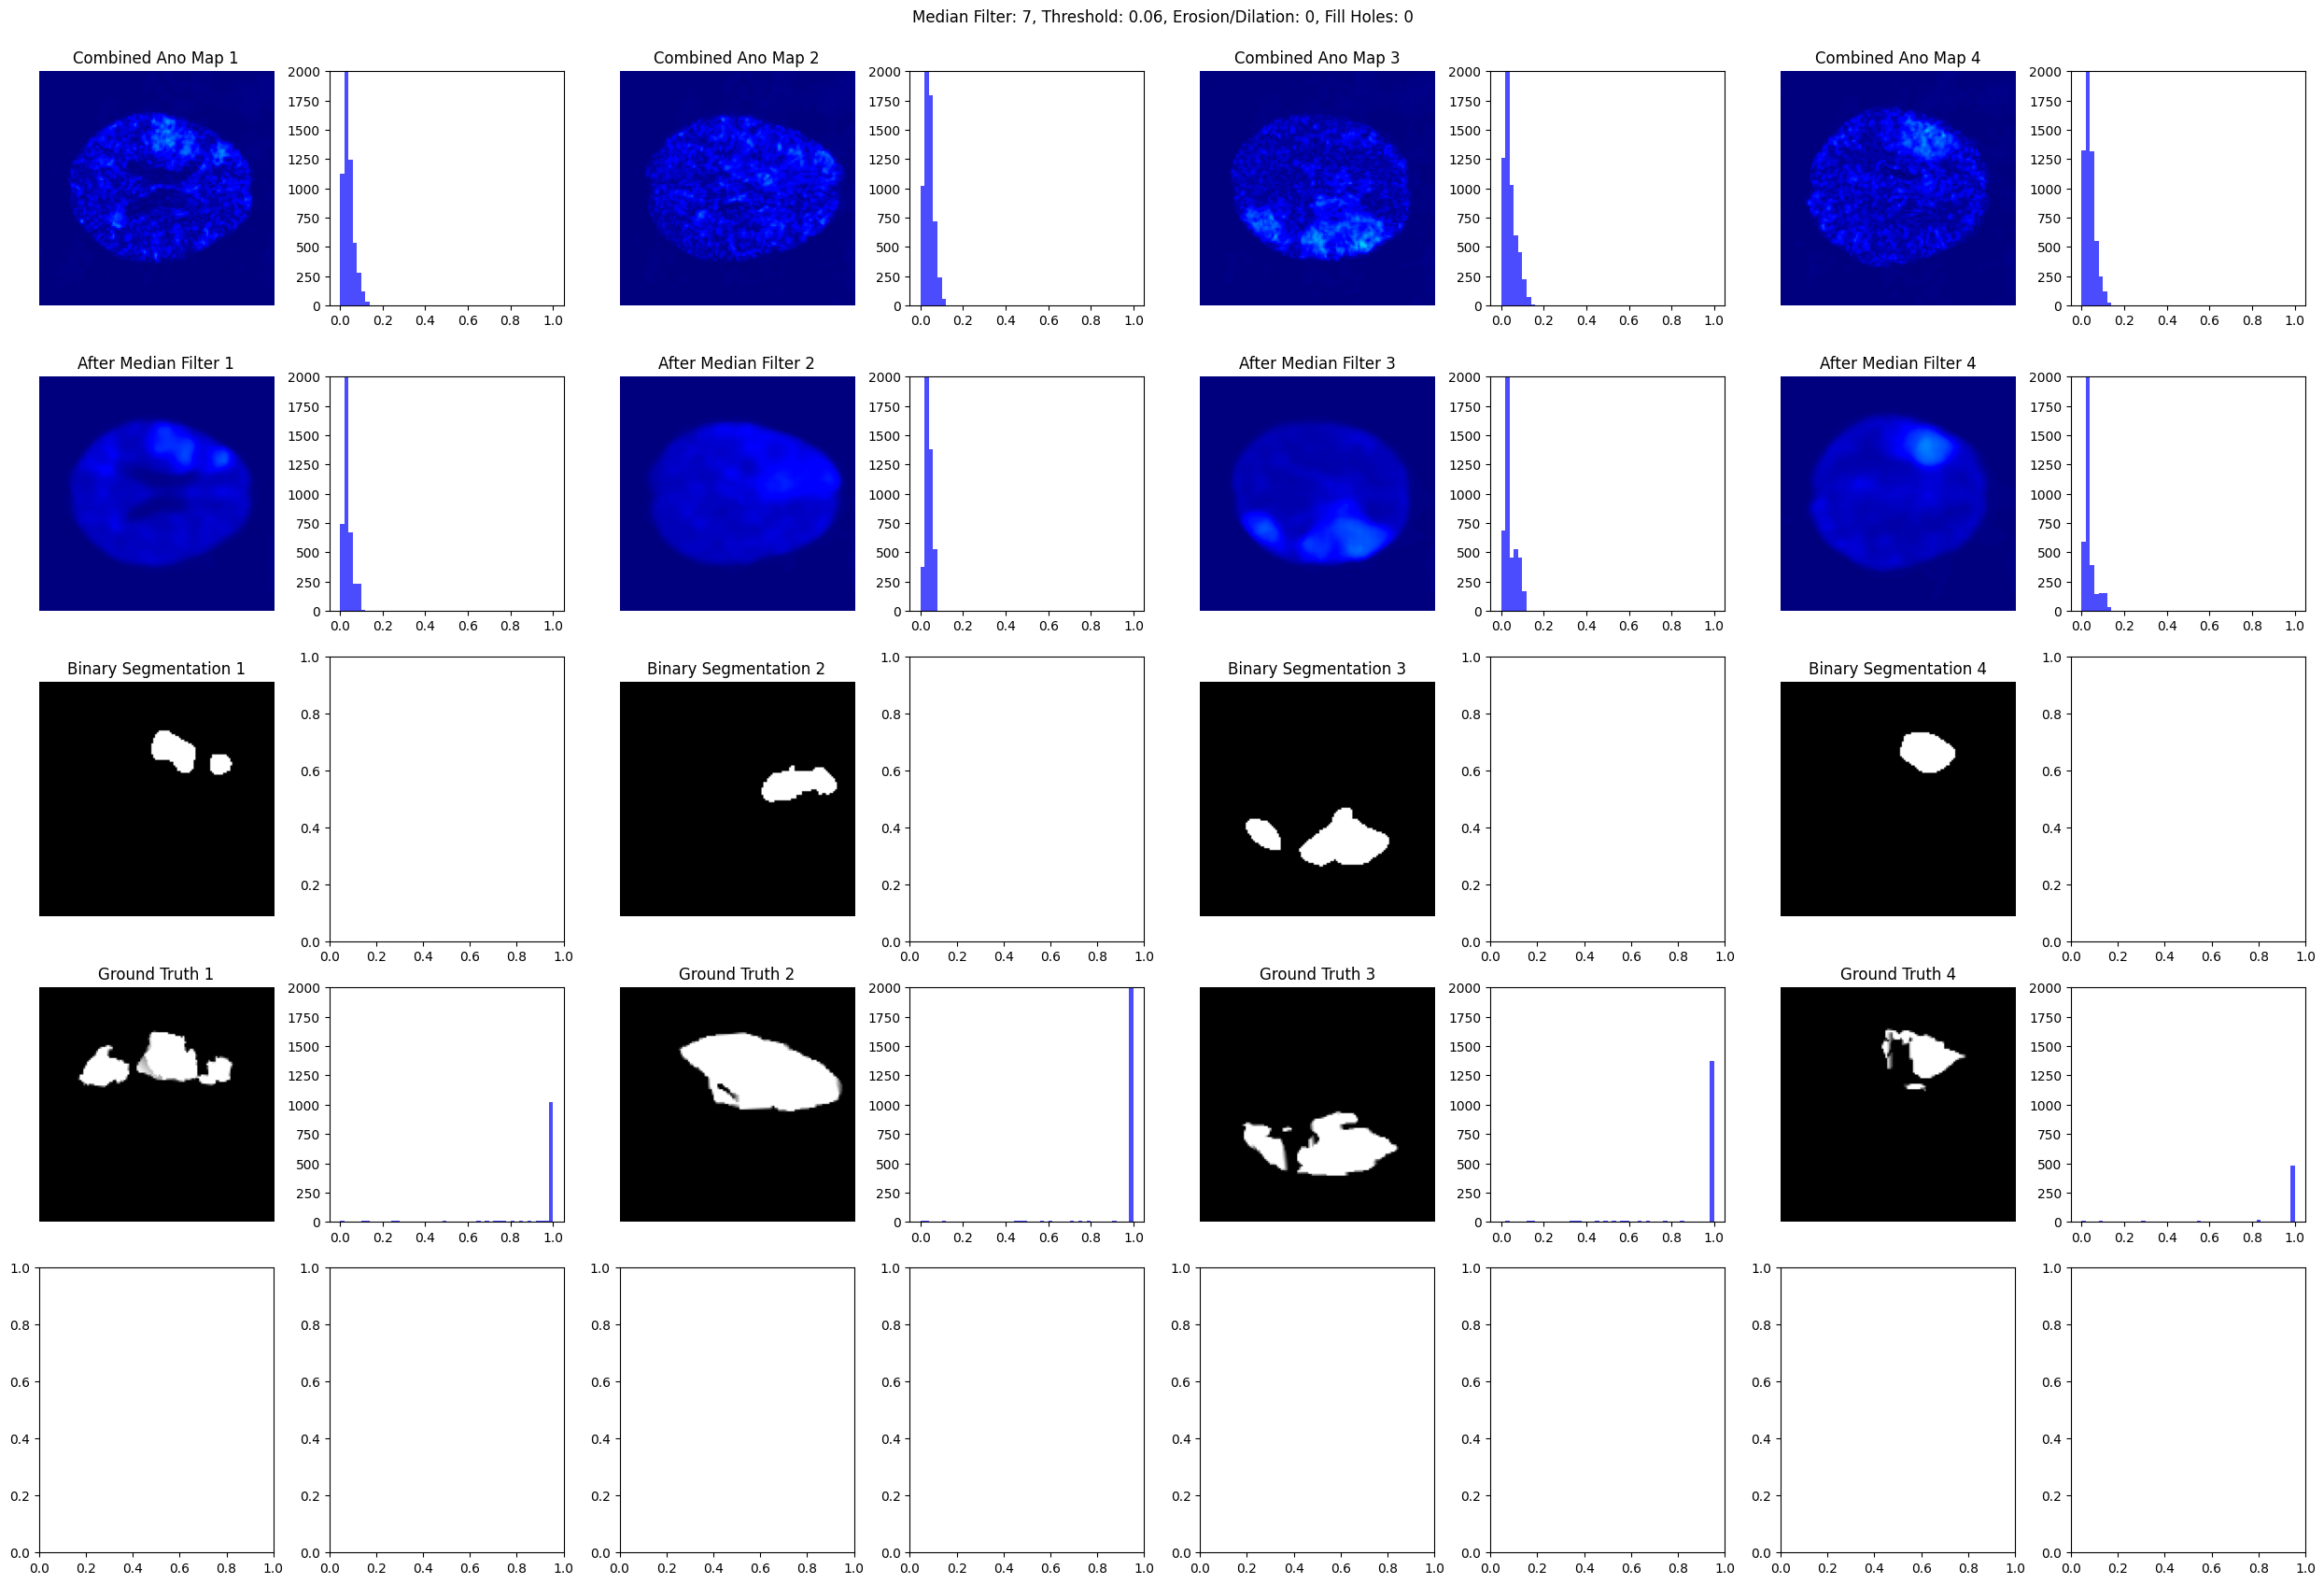

In [20]:
# ----------- PLOT -----------

fig, axes = plt.subplots(5, 8, figsize=(25, 17), constrained_layout=True)
plt.tight_layout()

# Load first 4 samples from combined anomaly maps
sample_files = combined_ano_maps[:4]

for idx, file in enumerate(sample_files):
    # Load combined anomaly map
    combined_map_path = os.path.join(combined_anomaly_maps_folder, file)
    combined_map_img = nib.load(combined_map_path)
    combined_map_data = combined_map_img.get_fdata()
    
    # Load ground truth mask
    mask_path = os.path.join(combined_masks_folder, file)
    mask_img = nib.load(mask_path)
    mask_data = mask_img.get_fdata()
    
    # Get middle slice for visualization
    slice_idx = combined_map_data.shape[-1] // 2
    original_slice = combined_map_data[:, :, slice_idx]
    
    # Original combined anomaly map
    axes[0, idx*2].imshow(original_slice, cmap='jet', vmin=0, vmax=0.5)
    axes[0, idx*2].set_title(f'Combined Ano Map {idx+1}')
    axes[0, idx*2].axis('off')
    
    axes[0, idx*2+1].hist(original_slice[original_slice>0.01].flatten(), bins=50, color='blue', alpha=0.7, range=(0.0, 1.0))
    axes[0, idx*2+1].set_ylim(0, 2000)
    axes[0, idx*2+1].set_aspect('auto')
    
    # Apply median filter
    if best_median_filter_size > 1:
        filtered_map = median_filter(combined_map_data, size=best_median_filter_size)
    else:
        filtered_map = combined_map_data
    
    filtered_slice = filtered_map[:, :, slice_idx]
    axes[1, idx*2].imshow(filtered_slice, cmap='jet', vmin=0, vmax=0.5)
    axes[1, idx*2].set_title(f'After Median Filter {idx+1}')
    axes[1, idx*2].axis('off')
    
    axes[1, idx*2+1].hist(filtered_slice[filtered_slice>0.01].flatten(), bins=50, color='blue', alpha=0.7, range=(0.0, 1.0))
    axes[1, idx*2+1].set_ylim(0, 2000)
    axes[1, idx*2+1].set_aspect('auto')
    
    # Apply threshold
    binary_mask = filtered_map > best_threshold
    
    # Apply erosion/dilation
    if best_erosion_dilation_iterations > 0:
        binary_mask = binary_erosion(binary_mask, iterations=best_erosion_dilation_iterations)
        binary_mask = binary_dilation(binary_mask, iterations=best_erosion_dilation_iterations)
    
    # Apply binary fill holes
    if best_binary_fill_holes:
        binary_mask = binary_fill_holes(binary_mask)
    
    binary_slice = binary_mask[:, :, slice_idx]
    axes[2, idx*2].imshow(binary_slice, cmap='gray', vmin=0, vmax=1)
    axes[2, idx*2].set_title(f'Binary Segmentation {idx+1}')
    axes[2, idx*2].axis('off')
    
    # Ground truth mask
    gt_slice = mask_data[:, :, slice_idx]
    axes[3, idx*2].imshow(gt_slice, cmap='gray', vmin=0, vmax=1)
    axes[3, idx*2].set_title(f'Ground Truth {idx+1}')
    axes[3, idx*2].axis('off')
    
    axes[3, idx*2+1].hist(gt_slice[gt_slice>0.01].flatten(), bins=50, color='blue', alpha=0.7, range=(0.0, 1.0))
    axes[3, idx*2+1].set_ylim(0, 2000)
    axes[3, idx*2+1].set_aspect('auto')
    
    # Set aspect ratios
    axes[0, idx*2+1].set_box_aspect(1)
    axes[1, idx*2+1].set_box_aspect(1)
    axes[3, idx*2+1].set_box_aspect(1)

# Add text with parameters
param_text = f'Median Filter: {best_median_filter_size}, Threshold: {best_threshold:.2f}, '
param_text += f'Erosion/Dilation: {best_erosion_dilation_iterations}, Fill Holes: {best_binary_fill_holes}'
fig.suptitle(param_text, fontsize=12, y=0.995)
plt.tight_layout()
plt.show()